In [10]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci
import matplotlib.dates as mdates
import numpy as np

In [11]:
eug = pd.read_csv("cleaned_eug.csv")                      # | Read in new, cleaned data |
spd = pd.read_csv("cleaned_spd.csv")                      # | Read in new, cleaned data |

In [12]:
eug['calltime'] = pd.to_datetime(eug['calltime'])           # | Convert calltime into datetime again |
eug_arrests = eug[eug["closed_as"] == "ARREST"]             # |        Subset to only arrests        |

spd['calltime'] = pd.to_datetime(spd['calltime'])           # | Convert calltime into datetime again |
spd_arrests = spd[spd["closed_as"] == "ARR"]                # |        Subset to only arrests        |

In [13]:
eug_counts = (eug_arrests
    .assign(date=eug_arrests['calltime'].dt.floor('D'))
    .groupby('date').size()
    .reindex(pd.date_range('2015-01-01', eug_arrests['calltime'].max(), freq='D'), fill_value=0)
    .rolling(30, min_periods=1).mean()
    .reset_index(name='count_eug')
    .rename(columns={'index': 'calltime'})
)

spd_counts = (spd_arrests
    .assign(date=spd_arrests['calltime'].dt.floor('D'))
    .groupby('date').size()
    .reindex(pd.date_range('2015-01-01', spd_arrests['calltime'].max(), freq='D'), fill_value=0)
    .rolling(30, min_periods=1).mean()
    .reset_index(name='count_spd')
    .rename(columns={'index': 'calltime'})
)

merged = pd.merge(eug_counts, spd_counts, on='calltime', how='outer')

In [14]:
treatment_date = pd.Timestamp('2025-04-07')

pre_date  = merged['calltime'] < treatment_date
post_date = merged['calltime'] >= treatment_date

eugene_pre_mean  = merged.loc[pre_date,  'count_eug'].mean()
eugene_post_mean = merged.loc[post_date, 'count_eug'].mean()

spd_pre_mean     = merged.loc[pre_date,  'count_spd'].mean()
spd_post_mean    = merged.loc[post_date, 'count_spd'].mean()

spd_change = spd_post_mean - spd_pre_mean

print(f"Eugene:      {eugene_pre_mean:.3f} → {eugene_post_mean:.3f}")
print(f"Springfield: {spd_pre_mean:.3f} → {spd_post_mean:.3f}")
print(f"DiD estimate: {(eugene_post_mean - eugene_pre_mean) - spd_change:.3f}")

Eugene:      0.207 → 0.350
Springfield: 0.014 → 0.025
DiD estimate: 0.133


In [15]:
pre_date  = merged['calltime'] < treatment_date
post_date = merged['calltime'] >= treatment_date

spd_pre_rate  = merged.loc[pre_date,  'count_spd'].mean()
spd_post_rate = merged.loc[post_date, 'count_spd'].mean()
spd_delta     = spd_post_rate - spd_pre_rate

post_dates      = merged.loc[post_date, 'calltime']
eugene_pre_mean = merged.loc[pre_date, 'count_eug'].mean()

# Tile the last year of pre-treatment Eugene forward -- FOR COUNTERFACTUAL LINE
last_year_pre = merged.loc[pre_date, 'count_eug'].tail(365).values
n_post = post_date.sum()
cf_values = np.tile(last_year_pre, int(np.ceil(n_post / 365)))[:n_post]
cf_line = pd.Series(cf_values, index=post_dates.index)

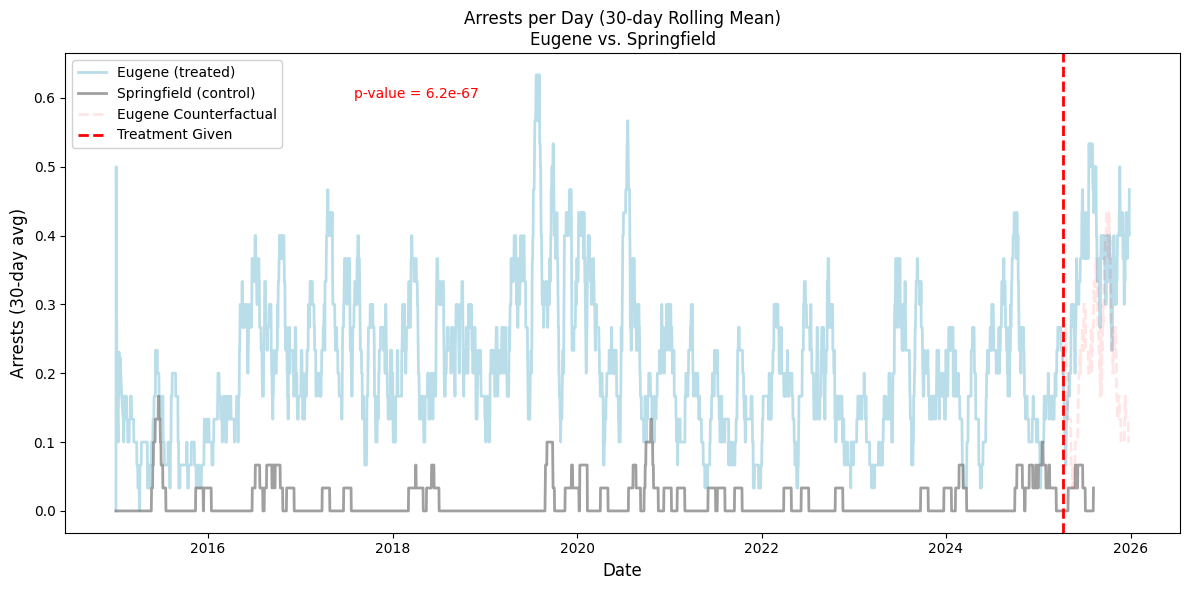

In [16]:
plt.figure(figsize=(12,6))

plt.plot(merged['calltime'], merged['count_eug'], label='Eugene (treated)', color='lightblue', linewidth=2, alpha=0.85)
plt.plot(merged['calltime'], merged['count_spd'], label='Springfield (control)', color='gray', linewidth=2, alpha=0.75)
plt.plot(post_dates, cf_line, linestyle='--', color='red', linewidth=2, alpha=0.1, label='Eugene Counterfactual')
plt.axvline(treatment_date, linestyle='--', color='red', linewidth=2, label='Treatment Given')

plt.title('Arrests per Day (30-day Rolling Mean)\nEugene vs. Springfield')
plt.ylabel('Arrests (30-day avg)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.text(pd.to_datetime("2017-08-01"), 0.6, "p-value = 6.2e-67", color='red')
plt.legend(loc='upper left', framealpha=0.9, fontsize=10)
 
plt.tight_layout()
plt.savefig("diff_in_diff_outcome.png", dpi=300)
plt.show()

#### Conduct T-Test

In [17]:
before_treatment = merged[merged["calltime"] < treatment_date]['count_eug']
after_treatment = merged[merged["calltime"] > treatment_date]['count_eug']
# Perform test
t_val, p = sci.ttest_ind(before_treatment, after_treatment, equal_var=False, nan_policy='omit')               # | Independent Two-Sample T-Test since sizes of before + after not same |
                                                                                                              # | equal_var=False since variances are NOT the same                     |
print(f"P-value: {p}")                                                                                        # | nan_policy="omit" since some observations are missing/nan            |

P-value: 6.208129227810834e-67


In [18]:
if p < 0.05:
    print("We reject the null hypothesis that the mean of the number of arrests concluding welfare check calls is the same after treatment.")
else: 
    print("We fail to reject the null hypothesis that the mean of the number of arrests concluding welfare check calls is the same after treatment.") 


We reject the null hypothesis that the mean of the number of arrests concluding welfare check calls is the same after treatment.


#### Explanation of DiD Analysis

What we see from this DiD plot is that before CAHOOTS was defunded and stopped its operations in Eugene, we saw, on average, less arrests in the years before 2025, but after CAHOOTS was defunded here in April of 2025, the number began to spike upwards, meaning that there are far more arrests. Comparing this to Springfield who kept CAHOOTS in operation, we see that the number of arrests remains somewhat constant. When conducting a t-test on Eugene arrests, the results say that with a p-value of 6.2e-67, that there indeed was a statistically significant increase in the number of arrests done in Eugene in a 30 day basis. 

#### Explanation of T-Test 

A t-test was conducted here to answer the question of whether or not the change in arrests after CAHOOTS stopped its operations in Eugene was significant. The null hypothesis ($H_0$) was that the mean of the number arrests concludiing a welfare check calls is the same after the treatment and the alternative hypothesis ($H_1%) is that there was a significant difference in the average volume of welfare check calls. In the end, the resulting p-value was 6.2e-67, concluding that we reject the null hypothesis and assume that there was a significant change in the number of arrests concluding from welfare check calls after CAHOOTS stopped operations. 